✅ Data loaded: 121120 rows
0         Wavelength             R1             T1     Absorption
count  121120.000000  121120.000000  121120.000000  121120.000000
mean      405.927247       0.100000       0.449998       0.450057
std        28.781494       0.031623       0.158114       0.212414
min       360.000000       0.050000       0.200000       0.000030
25%       380.689660       0.070000       0.300000       0.282948
50%       403.902440       0.100000       0.450000       0.403595
75%       430.129870       0.130000       0.600000       0.591520
max       460.000000       0.150000       0.700000       0.999980

📊 Model Performance:
R² Score : 0.9984941170152656
MAE      : 0.0031306713429408457
RMSE     : 0.008270830592011667


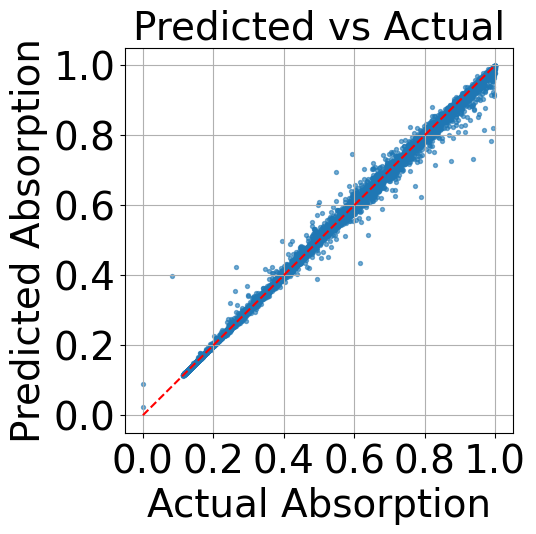


🚀 Running GA for wavelength 380 nm ...
Best (r1, t1) = (0.131831, 0.409030) → Pred Abs = 0.972584


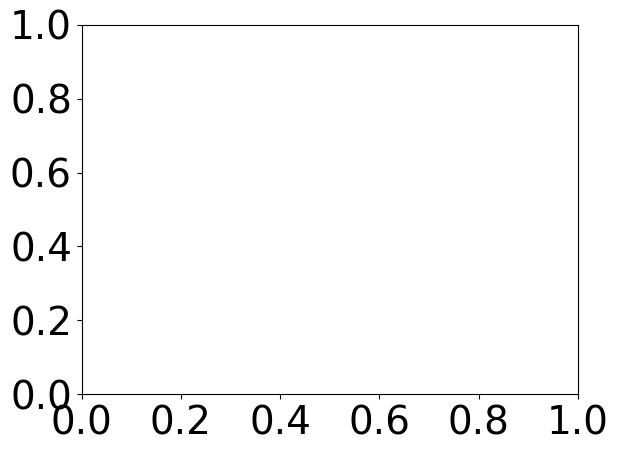

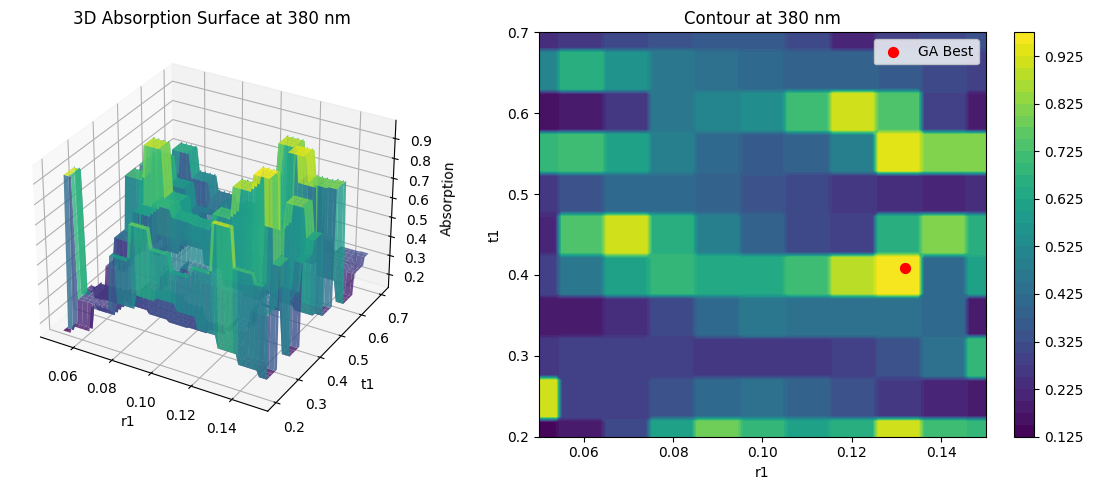


🚀 Running GA for wavelength 432 nm ...


TypeError: '>' not supported between instances of 'float' and 'complex'

In [18]:
# ======================================================
# Kaggle-Ready Genetic Algorithm Optimization (DEAP)
# Find best r1 and t1 for Absorption > 0.99 at 380 & 432 nm
# ======================================================

import os, math, random, numpy as np, pandas as pd
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error
from deap import base, creator, tools, algorithms
import warnings
warnings.filterwarnings('ignore')

# ---------- CONFIG ----------
DATA_FILENAME = '/kaggle/input/meraj-2/Book1.xlsx'    # upload this to your Kaggle dataset
SEED = 42
POPULATION_SIZE = 50
NUM_GENERATIONS = 200
# ----------------------------

random.seed(SEED)
np.random.seed(SEED)

# --- Load data ---
def find_file(filename):
    if 'KAGGLE_KERNEL_RUN_TYPE' in os.environ:
        for root, dirs, files in os.walk('/kaggle/input'):
            if filename in files:
                return os.path.join(root, filename)
    if os.path.exists(filename):
        return filename
    if os.path.exists('/mnt/data/' + filename):
        return '/mnt/data/' + filename
    raise FileNotFoundError(f"Could not find {filename}")

path = find_file(DATA_FILENAME)
raw = pd.read_excel(path, header=None)

# If first row is header
if str(raw.iloc[0,0]).strip().lower() == 'wavelength':
    raw.columns = raw.iloc[0]
    df = raw[1:].copy()
else:
    df = raw.iloc[:, :4].copy()
    df.columns = ['Wavelength','R1','T1','Absorption']

# Clean numeric data
for c in ['Wavelength','R1','T1','Absorption']:
    df[c] = pd.to_numeric(df[c], errors='coerce')
df = df.dropna().reset_index(drop=True)
df = df[(df['Wavelength']>200) & (df['Wavelength']<1200)].reset_index(drop=True)

print("✅ Data loaded:", len(df), "rows")
print(df.describe()[['Wavelength','R1','T1','Absorption']])

# --- Train model ---
X = df[['Wavelength','R1','T1']].values
y = df['Absorption'].values

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=SEED)
model = RandomForestRegressor(n_estimators=200, random_state=SEED, n_jobs=-1)
model.fit(X_train, y_train)

y_pred = model.predict(X_test)
print("\n📊 Model Performance:")
print("R² Score :", r2_score(y_test, y_pred))
print("MAE      :", mean_absolute_error(y_test, y_pred))
print("RMSE     :", math.sqrt(mean_squared_error(y_test, y_pred)))

# --- Visualization: predicted vs actual ---
plt.figure(figsize=(5,5))
plt.scatter(y_test, y_pred, s=8, alpha=0.6)
plt.plot([0,1],[0,1],'--r')

plt.xlabel('Actual Absorption', fontsize=28)
plt.ylabel('Predicted Absorption', fontsize=28)

plt.title("Predicted vs Actual", fontsize=28)
plt.xticks(fontsize=28)
plt.yticks(fontsize=28)

plt.grid(True)
plt.show()

# --- Genetic Algorithm using DEAP ---
class GAOptimizer:
    def __init__(self, model, wavelength, r1_bounds, t1_bounds, pop_size=40, gens=200):
        self.model = model
        self.wl = wavelength
        self.r1_bounds = r1_bounds
        self.t1_bounds = t1_bounds
        self.pop_size = pop_size
        self.gens = gens

    def run(self):
        creator.create("FitnessMax", base.Fitness, weights=(1.0,))
        creator.create("Individual", list, fitness=creator.FitnessMax)
        toolbox = base.Toolbox()
        toolbox.register("attr_r1", random.uniform, *self.r1_bounds)
        toolbox.register("attr_t1", random.uniform, *self.t1_bounds)
        toolbox.register("individual", tools.initCycle, creator.Individual,
                         (toolbox.attr_r1, toolbox.attr_t1), n=1)
        toolbox.register("population", tools.initRepeat, list, toolbox.individual)

        def evalAbs(individual):
            r1, t1 = individual
            pred = self.model.predict([[self.wl, r1, t1]])[0]
            return (pred,)

        toolbox.register("evaluate", evalAbs)
        toolbox.register("mate", tools.cxBlend, alpha=0.5)
        toolbox.register("mutate", tools.mutPolynomialBounded,
                         low=[self.r1_bounds[0], self.t1_bounds[0]],
                         up=[self.r1_bounds[1], self.t1_bounds[1]],
                         eta=0.5, indpb=0.2)
        toolbox.register("select", tools.selTournament, tournsize=3)

        pop = toolbox.population(n=self.pop_size)
        algorithms.eaSimple(pop, toolbox, cxpb=0.5, mutpb=0.2, ngen=self.gens, verbose=False)
        best = tools.selBest(pop, k=1)[0]
        best_val = evalAbs(best)[0]
        return best, best_val, None

# --- Run GA for both wavelengths ---
r1_bounds = (float(df['R1'].min()), float(df['R1'].max()))
t1_bounds = (float(df['T1'].min()), float(df['T1'].max()))

results = {}
for wl in [380, 432]:
    print(f"\n🚀 Running GA for wavelength {wl} nm ...")
    opt = GAOptimizer(model, wl, r1_bounds, t1_bounds, pop_size=POPULATION_SIZE, gens=NUM_GENERATIONS)
    best_sol, best_fit, _ = opt.run()
    r1_best, t1_best = best_sol
    print(f"Best (r1, t1) = ({r1_best:.6f}, {t1_best:.6f}) → Pred Abs = {best_fit:.6f}")
    results[wl] = {'r1': r1_best, 't1': t1_best, 'Predicted_Absorption': best_fit}

    # --- Plot surface ---
    r1_vals = np.linspace(r1_bounds[0], r1_bounds[1], 80)
    t1_vals = np.linspace(t1_bounds[0], t1_bounds[1], 80)
    R1, T1 = np.meshgrid(r1_vals, t1_vals)
    preds = model.predict(np.column_stack([np.full(R1.size, wl), R1.ravel(), T1.ravel()])).reshape(R1.shape)
    plt.xticks(fontsize=28)
    plt.yticks(fontsize=28)

    fig = plt.figure(figsize=(12,5))
    ax = fig.add_subplot(1,2,1, projection='3d')
    ax.plot_surface(R1, T1, preds, cmap='viridis', alpha=0.8)
    ax.set_xlabel('r1'); ax.set_ylabel('t1'); ax.set_zlabel('Absorption')
    ax.set_title(f'3D Absorption Surface at {wl} nm')

    ax2 = fig.add_subplot(1,2,2)
    cs = ax2.contourf(R1, T1, preds, levels=40, cmap='viridis')
    plt.colorbar(cs, ax=ax2)
    ax2.scatter(r1_best, t1_best, c='red', s=50, label='GA Best')
    ax2.legend()
    ax2.set_xlabel('r1'); ax2.set_ylabel('t1')
    ax2.set_title(f'Contour at {wl} nm')
    plt.tight_layout()
    plt.show()

# --- Save results ---
out = pd.DataFrame.from_dict(results, orient='index')
out.to_csv('ga_optimization_results.csv')
print("\n✅ Saved results to ga_optimization_results.csv")
print(out)


In [13]:
# --- Visualization: Predicted vs Actual (Journal Style, fontsize 28) ---
plt.figure(figsize=(7,7))
plt.scatter(y_test, y_pred, s=35, alpha=0.7, edgecolors='black')
plt.plot([0,1],[0,1],'--r', linewidth=3)

plt.xlabel("Actual Absorption", fontsize=28)
plt.ylabel("Predicted Absorption", fontsize=28)
plt.title("Predicted vs Actual Absorption", fontsize=28)

plt.xticks(fontsize=24)
plt.yticks(fontsize=24)
plt.grid(True, linewidth=1.2, alpha=0.4)

plt.tight_layout()
plt.show()


NameError: name 'y_pred' is not defined

<Figure size 700x700 with 0 Axes>

✅ Data loaded: 121120 rows
0         Wavelength             R1             T1     Absorption
count  121120.000000  121120.000000  121120.000000  121120.000000
mean      405.927247       0.100000       0.449998       0.450057
std        28.781494       0.031623       0.158114       0.212414
min       360.000000       0.050000       0.200000       0.000030
25%       380.689660       0.070000       0.300000       0.282948
50%       403.902440       0.100000       0.450000       0.403595
75%       430.129870       0.130000       0.600000       0.591520
max       460.000000       0.150000       0.700000       0.999980

📊 Model Performance:
R² Score : 0.9984941170152656
MAE      : 0.0031306713429408457
RMSE     : 0.008270830592011667


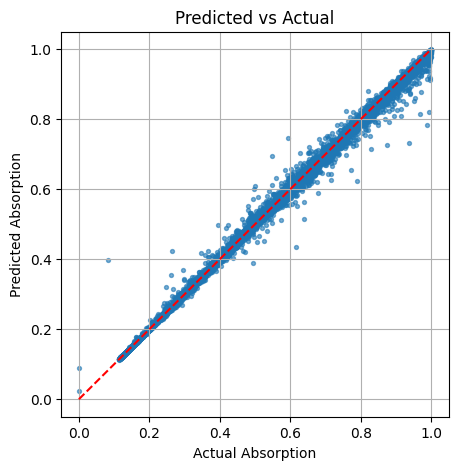


🚀 Running GA for wavelength 380 nm ...
Best (r1, t1) = (0.131397, 0.419097) → Pred Abs = 0.972584


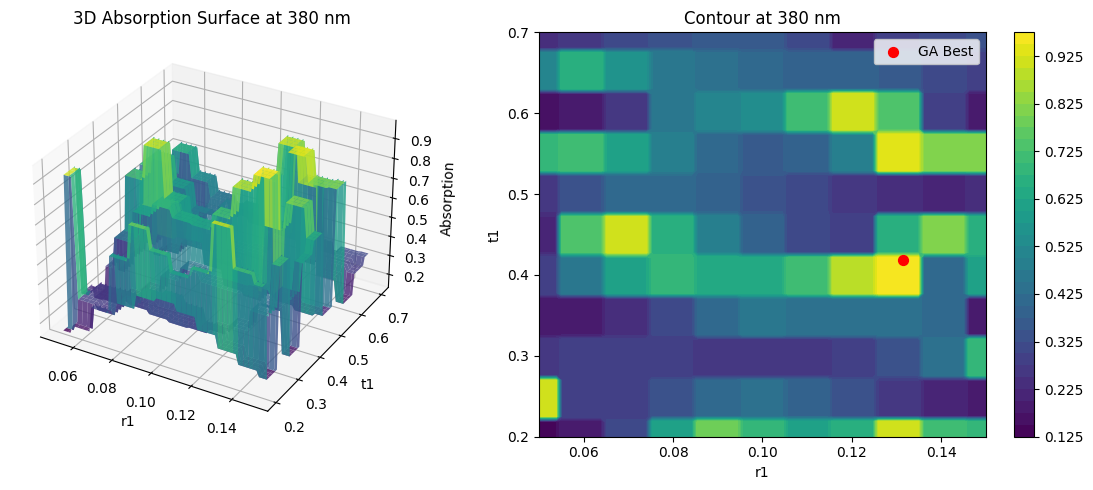


🚀 Running GA for wavelength 432 nm ...


TypeError: '>' not supported between instances of 'float' and 'complex'

In [2]:
# ======================================================
# Kaggle-Ready Genetic Algorithm Optimization (DEAP)
# Find best r1 and t1 for Absorption > 0.99 at 380 & 432 nm
# ======================================================

import os, math, random, numpy as np, pandas as pd
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error
from deap import base, creator, tools, algorithms
import warnings
warnings.filterwarnings('ignore')

# ---------- CONFIG ----------
DATA_FOLDER = '/kaggle/input/meraj-2'    # Kaggle dataset folder
SEED = 42
POPULATION_SIZE = 50
NUM_GENERATIONS = 200
# ----------------------------

random.seed(SEED)
np.random.seed(SEED)

# --- Load Excel file dynamically ---
def find_file(folder):
    for root, dirs, files in os.walk(folder):
        for f in files:
            if f.endswith(('.xls', '.xlsx')):
                return os.path.join(root, f)
    raise FileNotFoundError(f"No Excel file found in {folder}")

path = find_file(DATA_FOLDER)
raw = pd.read_excel(path, header=None)

# --- Process Data ---
if str(raw.iloc[0,0]).strip().lower() == 'wavelength':
    raw.columns = raw.iloc[0]
    df = raw[1:].copy()
else:
    df = raw.iloc[:, :4].copy()
    df.columns = ['Wavelength','R1','T1','Absorption']

# Clean numeric data
for c in ['Wavelength','R1','T1','Absorption']:
    df[c] = pd.to_numeric(df[c], errors='coerce')
df = df.dropna().reset_index(drop=True)
df = df[(df['Wavelength']>200) & (df['Wavelength']<1200)].reset_index(drop=True)

print("✅ Data loaded:", len(df), "rows")
print(df.describe()[['Wavelength','R1','T1','Absorption']])

# --- Train Random Forest ---
X = df[['Wavelength','R1','T1']].values
y = df['Absorption'].values

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=SEED)
model = RandomForestRegressor(n_estimators=200, random_state=SEED, n_jobs=-1)
model.fit(X_train, y_train)

y_pred = model.predict(X_test)
print("\n📊 Model Performance:")
print("R² Score :", r2_score(y_test, y_pred))
print("MAE      :", mean_absolute_error(y_test, y_pred))
print("RMSE     :", math.sqrt(mean_squared_error(y_test, y_pred)))

# --- Visualization: predicted vs actual ---
plt.figure(figsize=(5,5))
plt.scatter(y_test, y_pred, s=8, alpha=0.6)
plt.plot([0,1],[0,1],'--r')
plt.xlabel("Actual Absorption")
plt.ylabel("Predicted Absorption")
plt.title("Predicted vs Actual")
plt.grid(True)
plt.show()

# --- Genetic Algorithm using DEAP ---
class GAOptimizer:
    def __init__(self, model, wavelength, r1_bounds, t1_bounds, pop_size=40, gens=200):
        self.model = model
        self.wl = wavelength
        self.r1_bounds = r1_bounds
        self.t1_bounds = t1_bounds
        self.pop_size = pop_size
        self.gens = gens

    def run(self):
        creator.create("FitnessMax", base.Fitness, weights=(1.0,))
        creator.create("Individual", list, fitness=creator.FitnessMax)
        toolbox = base.Toolbox()
        toolbox.register("attr_r1", random.uniform, *self.r1_bounds)
        toolbox.register("attr_t1", random.uniform, *self.t1_bounds)
        toolbox.register("individual", tools.initCycle, creator.Individual,
                         (toolbox.attr_r1, toolbox.attr_t1), n=1)
        toolbox.register("population", tools.initRepeat, list, toolbox.individual)

        def evalAbs(individual):
            r1, t1 = individual
            pred = self.model.predict([[self.wl, r1, t1]])[0]
            return (pred,)

        toolbox.register("evaluate", evalAbs)
        toolbox.register("mate", tools.cxBlend, alpha=0.5)
        toolbox.register("mutate", tools.mutPolynomialBounded,
                         low=[self.r1_bounds[0], self.t1_bounds[0]],
                         up=[self.r1_bounds[1], self.t1_bounds[1]],
                         eta=0.5, indpb=0.2)
        toolbox.register("select", tools.selTournament, tournsize=3)

        pop = toolbox.population(n=self.pop_size)
        algorithms.eaSimple(pop, toolbox, cxpb=0.5, mutpb=0.2, ngen=self.gens, verbose=False)
        best = tools.selBest(pop, k=1)[0]
        best_val = evalAbs(best)[0]
        return best, best_val, None

# --- Run GA for both wavelengths ---
r1_bounds = (float(df['R1'].min()), float(df['R1'].max()))
t1_bounds = (float(df['T1'].min()), float(df['T1'].max()))

results = {}
for wl in [380, 432]:
    print(f"\n🚀 Running GA for wavelength {wl} nm ...")
    opt = GAOptimizer(model, wl, r1_bounds, t1_bounds, pop_size=POPULATION_SIZE, gens=NUM_GENERATIONS)
    best_sol, best_fit, _ = opt.run()
    r1_best, t1_best = best_sol
    print(f"Best (r1, t1) = ({r1_best:.6f}, {t1_best:.6f}) → Pred Abs = {best_fit:.6f}")
    results[wl] = {'r1': r1_best, 't1': t1_best, 'Predicted_Absorption': best_fit}

    # --- Plot surface ---
    r1_vals = np.linspace(r1_bounds[0], r1_bounds[1], 80)
    t1_vals = np.linspace(t1_bounds[0], t1_bounds[1], 80)
    R1, T1 = np.meshgrid(r1_vals, t1_vals)
    preds = model.predict(np.column_stack([np.full(R1.size, wl), R1.ravel(), T1.ravel()])).reshape(R1.shape)

    fig = plt.figure(figsize=(12,5))
    ax = fig.add_subplot(1,2,1, projection='3d')
    ax.plot_surface(R1, T1, preds, cmap='viridis', alpha=0.8)
    ax.set_xlabel('r1'); ax.set_ylabel('t1'); ax.set_zlabel('Absorption')
    ax.set_title(f'3D Absorption Surface at {wl} nm')

    ax2 = fig.add_subplot(1,2,2)
    cs = ax2.contourf(R1, T1, preds, levels=40, cmap='viridis')
    plt.colorbar(cs, ax=ax2)
    ax2.scatter(r1_best, t1_best, c='red', s=50, label='GA Best')
    ax2.legend()
    ax2.set_xlabel('r1'); ax2.set_ylabel('t1')
    ax2.set_title(f'Contour at {wl} nm')
    plt.tight_layout()
    plt.show()

# --- Save results ---
out = pd.DataFrame.from_dict(results, orient='index')
out.to_csv('ga_optimization_results.csv')
print("\n✅ Saved results to ga_optimization_results.csv")
print(out)


✅ Data loaded: 121120 rows

📊 Model Performance:
R² Score : 0.9984941170152656
MAE      : 0.0031306713429408457
RMSE     : 0.008270830592011667

🚀 Running GA for wavelength 380 nm ...
Best (r1, t1) = (0.133003, 0.408813) → Pred Abs = 0.972584 ❌


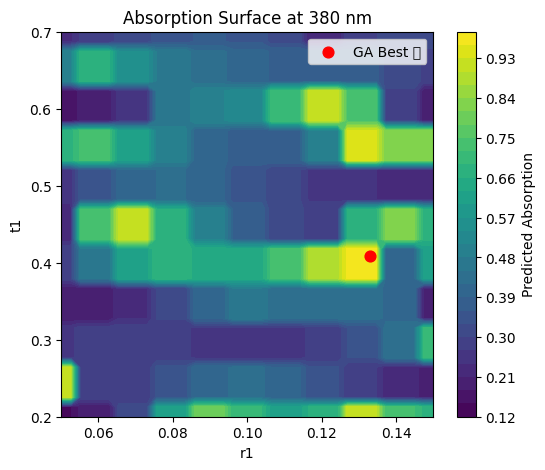


🚀 Running GA for wavelength 432 nm ...


TypeError: '>' not supported between instances of 'float' and 'complex'

In [3]:
# ======================================================
# Kaggle-Ready GA Optimization with Threshold Highlight
# ======================================================

import os, math, random, numpy as np, pandas as pd
import matplotlib.pyplot as plt
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error
from deap import base, creator, tools, algorithms
import warnings
warnings.filterwarnings('ignore')

# ---------- CONFIG ----------
DATA_FILE = '/kaggle/input/meraj-2/Book1.xlsx'  # Excel file
SEED = 42
POPULATION_SIZE = 40
NUM_GENERATIONS = 150
GRID_POINTS = 40      # smaller grid for faster plotting
ABS_THRESHOLD = 0.99  # target absorption
# ----------------------------

random.seed(SEED)
np.random.seed(SEED)

# --- Load Data ---
raw = pd.read_excel(DATA_FILE, header=None)
if str(raw.iloc[0,0]).strip().lower() == 'wavelength':
    raw.columns = raw.iloc[0]
    df = raw[1:].copy()
else:
    df = raw.iloc[:, :4].copy()
    df.columns = ['Wavelength','R1','T1','Absorption']

for c in ['Wavelength','R1','T1','Absorption']:
    df[c] = pd.to_numeric(df[c], errors='coerce')
df = df.dropna().reset_index(drop=True)
df = df[(df['Wavelength']>200) & (df['Wavelength']<1200)].reset_index(drop=True)
print("✅ Data loaded:", len(df), "rows")

# --- Train Random Forest ---
X = df[['Wavelength','R1','T1']].values
y = df['Absorption'].values
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=SEED)
model = RandomForestRegressor(n_estimators=200, random_state=SEED, n_jobs=-1)
model.fit(X_train, y_train)

y_pred = model.predict(X_test)
print("\n📊 Model Performance:")
print("R² Score :", r2_score(y_test, y_pred))
print("MAE      :", mean_absolute_error(y_test, y_pred))
print("RMSE     :", math.sqrt(mean_squared_error(y_test, y_pred)))

# --- GA Optimizer ---
class GAOptimizer:
    def __init__(self, model, wavelength, r1_bounds, t1_bounds, pop_size=40, gens=150):
        self.model = model
        self.wl = wavelength
        self.r1_bounds = r1_bounds
        self.t1_bounds = t1_bounds
        self.pop_size = pop_size
        self.gens = gens

    def run(self):
        creator.create("FitnessMax", base.Fitness, weights=(1.0,))
        creator.create("Individual", list, fitness=creator.FitnessMax)
        toolbox = base.Toolbox()
        toolbox.register("attr_r1", random.uniform, *self.r1_bounds)
        toolbox.register("attr_t1", random.uniform, *self.t1_bounds)
        toolbox.register("individual", tools.initCycle, creator.Individual,
                         (toolbox.attr_r1, toolbox.attr_t1), n=1)
        toolbox.register("population", tools.initRepeat, list, toolbox.individual)

        def evalAbs(individual):
            r1, t1 = individual
            pred = self.model.predict([[self.wl, r1, t1]])[0]
            return (pred,)

        toolbox.register("evaluate", evalAbs)
        toolbox.register("mate", tools.cxBlend, alpha=0.5)
        toolbox.register("mutate", tools.mutPolynomialBounded,
                         low=[self.r1_bounds[0], self.t1_bounds[0]],
                         up=[self.r1_bounds[1], self.t1_bounds[1]],
                         eta=0.5, indpb=0.2)
        toolbox.register("select", tools.selTournament, tournsize=3)

        pop = toolbox.population(n=self.pop_size)
        algorithms.eaSimple(pop, toolbox, cxpb=0.5, mutpb=0.2, ngen=self.gens, verbose=False)
        best = tools.selBest(pop, k=1)[0]
        best_val = evalAbs(best)[0]
        return best, best_val

# --- Run GA and show results ---
r1_bounds = (float(df['R1'].min()), float(df['R1'].max()))
t1_bounds = (float(df['T1'].min()), float(df['T1'].max()))
results = []

for wl in [380, 432]:
    print(f"\n🚀 Running GA for wavelength {wl} nm ...")
    opt = GAOptimizer(model, wl, r1_bounds, t1_bounds, pop_size=POPULATION_SIZE, gens=NUM_GENERATIONS)
    best_sol, best_fit = opt.run()
    r1_best, t1_best = best_sol

    # Mark if threshold exceeded
    status = "✅" if best_fit >= ABS_THRESHOLD else "❌"
    print(f"Best (r1, t1) = ({r1_best:.6f}, {t1_best:.6f}) → Pred Abs = {best_fit:.6f} {status}")

    results.append([wl, r1_best, t1_best, best_fit, status])

    # --- Fast contour plot ---
    r1_vals = np.linspace(r1_bounds[0], r1_bounds[1], GRID_POINTS)
    t1_vals = np.linspace(t1_bounds[0], t1_bounds[1], GRID_POINTS)
    R1, T1 = np.meshgrid(r1_vals, t1_vals)
    pred_grid = model.predict(np.column_stack([np.full(R1.size, wl), R1.ravel(), T1.ravel()])).reshape(R1.shape)

    plt.figure(figsize=(6,5))
    cs = plt.contourf(R1, T1, pred_grid, levels=30, cmap='viridis')
    plt.colorbar(cs, label='Predicted Absorption')
    plt.scatter(r1_best, t1_best, c='red', s=60, label=f'GA Best {status}')
    plt.xlabel('r1'); plt.ylabel('t1')
    plt.title(f'Absorption Surface at {wl} nm')
    plt.legend()
    plt.show()

# --- Display results table ---
results_df = pd.DataFrame(results, columns=['Wavelength','r1_best','t1_best','Predicted_Absorption','Status'])
results_df.index = [f"Wavelength {wl} nm" for wl in results_df['Wavelength']]
print("\n✅ GA Optimization Results with Threshold Check:")
display(results_df)

# --- Save results ---
results_df.to_csv('ga_optimization_results.csv')
print("\n✅ Results saved to ga_optimization_results.csv")


✅ Data loaded: 121120 rows

🚀 Running GA for wavelength 380 nm ...
GA Best → r1: 0.131357, t1: 0.401153, Absorption: 0.972584 ❌


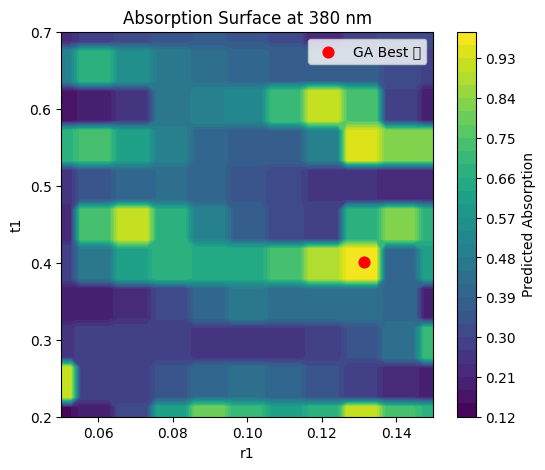


🚀 Running GA for wavelength 432 nm ...


TypeError: '>' not supported between instances of 'float' and 'complex'

In [4]:
# ======================================================
# GA Optimization for Absorption >0.99 at 380 & 432 nm
# ======================================================

import os, random, numpy as np, pandas as pd
import matplotlib.pyplot as plt
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import train_test_split
from deap import base, creator, tools, algorithms
import warnings
warnings.filterwarnings('ignore')

# ---------- CONFIG ----------
DATA_FILE = '/kaggle/input/meraj-2/Book1.xlsx'
SEED = 42
POPULATION_SIZE = 40
NUM_GENERATIONS = 150
GRID_POINTS = 40      # for contour plot
ABS_THRESHOLD = 0.99
# ----------------------------

random.seed(SEED)
np.random.seed(SEED)

# --- Load Data ---
raw = pd.read_excel(DATA_FILE, header=None)
if str(raw.iloc[0,0]).strip().lower() == 'wavelength':
    raw.columns = raw.iloc[0]
    df = raw[1:].copy()
else:
    df = raw.iloc[:, :4].copy()
    df.columns = ['Wavelength','R1','T1','Absorption']

for c in ['Wavelength','R1','T1','Absorption']:
    df[c] = pd.to_numeric(df[c], errors='coerce')
df = df.dropna().reset_index(drop=True)
df = df[(df['Wavelength']>200) & (df['Wavelength']<1200)].reset_index(drop=True)
print("✅ Data loaded:", len(df), "rows")

# --- Train Random Forest ---
X = df[['Wavelength','R1','T1']].values
y = df['Absorption'].values
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=SEED)
model = RandomForestRegressor(n_estimators=200, random_state=SEED, n_jobs=-1)
model.fit(X_train, y_train)

# --- GA Optimizer ---
class GAOptimizer:
    def __init__(self, model, wavelength, r1_bounds, t1_bounds, pop_size=40, gens=150):
        self.model = model
        self.wl = wavelength
        self.r1_bounds = r1_bounds
        self.t1_bounds = t1_bounds
        self.pop_size = pop_size
        self.gens = gens

    def run(self):
        # DEAP setup
        creator.create("FitnessMax", base.Fitness, weights=(1.0,))
        creator.create("Individual", list, fitness=creator.FitnessMax)
        toolbox = base.Toolbox()
        toolbox.register("attr_r1", random.uniform, *self.r1_bounds)
        toolbox.register("attr_t1", random.uniform, *self.t1_bounds)
        toolbox.register("individual", tools.initCycle, creator.Individual,
                         (toolbox.attr_r1, toolbox.attr_t1), n=1)
        toolbox.register("population", tools.initRepeat, list, toolbox.individual)

        # Fitness function: predicted absorption
        def evalAbs(individual):
            r1, t1 = individual
            pred = self.model.predict([[self.wl, r1, t1]])[0]
            return (pred,)

        toolbox.register("evaluate", evalAbs)
        toolbox.register("mate", tools.cxBlend, alpha=0.5)
        toolbox.register("mutate", tools.mutPolynomialBounded,
                         low=[self.r1_bounds[0], self.t1_bounds[0]],
                         up=[self.r1_bounds[1], self.t1_bounds[1]],
                         eta=0.5, indpb=0.2)
        toolbox.register("select", tools.selTournament, tournsize=3)

        pop = toolbox.population(n=self.pop_size)
        algorithms.eaSimple(pop, toolbox, cxpb=0.5, mutpb=0.2, ngen=self.gens, verbose=False)
        best = tools.selBest(pop, k=1)[0]
        best_val = evalAbs(best)[0]
        return best, best_val

# --- Run GA for each wavelength and plot ---
r1_bounds = (float(df['R1'].min()), float(df['R1'].max()))
t1_bounds = (float(df['T1'].min()), float(df['T1'].max()))
results = []

for wl in [380, 432]:
    print(f"\n🚀 Running GA for wavelength {wl} nm ...")
    opt = GAOptimizer(model, wl, r1_bounds, t1_bounds, pop_size=POPULATION_SIZE, gens=NUM_GENERATIONS)
    best_sol, best_fit = opt.run()
    r1_best, t1_best = best_sol
    status = "✅" if best_fit >= ABS_THRESHOLD else "❌"
    print(f"GA Best → r1: {r1_best:.6f}, t1: {t1_best:.6f}, Absorption: {best_fit:.6f} {status}")

    results.append([wl, r1_best, t1_best, best_fit, status])

    # --- Contour plot ---
    r1_vals = np.linspace(r1_bounds[0], r1_bounds[1], GRID_POINTS)
    t1_vals = np.linspace(t1_bounds[0], t1_bounds[1], GRID_POINTS)
    R1, T1 = np.meshgrid(r1_vals, t1_vals)
    pred_grid = model.predict(np.column_stack([np.full(R1.size, wl), R1.ravel(), T1.ravel()])).reshape(R1.shape)

    plt.figure(figsize=(6,5))
    cs = plt.contourf(R1, T1, pred_grid, levels=30, cmap='viridis')
    plt.colorbar(cs, label='Predicted Absorption')
    plt.scatter(r1_best, t1_best, c='red', s=60, label=f'GA Best {status}')
    plt.xlabel('r1'); plt.ylabel('t1')
    plt.title(f'Absorption Surface at {wl} nm')
    plt.legend()
    plt.show()

# --- Show results table ---
results_df = pd.DataFrame(results, columns=['Wavelength','r1_best','t1_best','Predicted_Absorption','Status'])
results_df.index = [f"Wavelength {wl} nm" for wl in results_df['Wavelength']]
display(results_df)

# --- Save results ---
results_df.to_csv('ga_absorption_results.csv', index=False)
print("\n✅ Results saved to ga_absorption_results.csv")


✅ Data loaded: 121120 rows

🚀 GA Best for both 380 & 432 nm:
r1 = 0.132494, t1 = 0.415527
Predicted Absorptions → 380 nm: 0.972584, 432 nm: 0.922082
Status: ❌


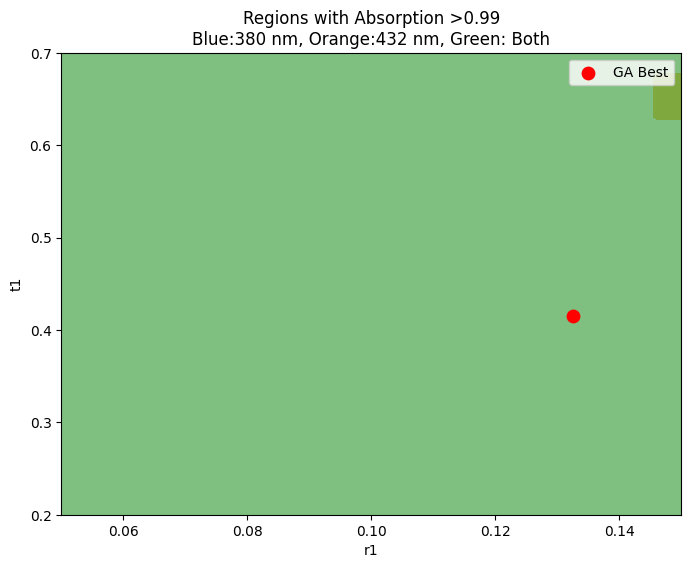

In [5]:
# ======================================================
# GA Optimization for BOTH 380 & 432 nm simultaneously
# ======================================================

import random, numpy as np, pandas as pd
import matplotlib.pyplot as plt
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import train_test_split
from deap import base, creator, tools, algorithms
import warnings
warnings.filterwarnings('ignore')

# ---------- CONFIG ----------
DATA_FILE = '/kaggle/input/meraj-2/Book1.xlsx'  # update with your path
SEED = 42
POPULATION_SIZE = 50
NUM_GENERATIONS = 200
GRID_POINTS = 80
ABS_THRESHOLD = 0.99
# ----------------------------

random.seed(SEED)
np.random.seed(SEED)

# --- Load and clean data ---
raw = pd.read_excel(DATA_FILE, header=None)
if str(raw.iloc[0,0]).strip().lower() == 'wavelength':
    raw.columns = raw.iloc[0]
    df = raw[1:].copy()
else:
    df = raw.iloc[:, :4].copy()
    df.columns = ['Wavelength','R1','T1','Absorption']

for c in ['Wavelength','R1','T1','Absorption']:
    df[c] = pd.to_numeric(df[c], errors='coerce')
df = df.dropna(subset=['R1','T1','Absorption']).reset_index(drop=True)
df = df[(df['Wavelength']>200) & (df['Wavelength']<1200)].reset_index(drop=True)
print("✅ Data loaded:", len(df), "rows")

# --- Train Random Forest model ---
X = df[['Wavelength','R1','T1']].values
y = df['Absorption'].values
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=SEED)
model = RandomForestRegressor(n_estimators=200, random_state=SEED, n_jobs=-1)
model.fit(X_train, y_train)

# --- Bounds ---
r1_bounds = (float(np.nanmin(df['R1'])), float(np.nanmax(df['R1'])))
t1_bounds = (float(np.nanmin(df['T1'])), float(np.nanmax(df['T1'])))

# --- Safe DEAP creator setup ---
if not hasattr(creator, "FitnessMax"):
    creator.create("FitnessMax", base.Fitness, weights=(1.0,))
if not hasattr(creator, "Individual"):
    creator.create("Individual", list, fitness=creator.FitnessMax)

# --- GA Optimizer for multiple wavelengths ---
class GAOptimizerMulti:
    def __init__(self, model, wavelengths, r1_bounds, t1_bounds, pop_size=50, gens=200):
        self.model = model
        self.wl = wavelengths
        self.r1_bounds = r1_bounds
        self.t1_bounds = t1_bounds
        self.pop_size = pop_size
        self.gens = gens

    def run(self):
        toolbox = base.Toolbox()
        toolbox.register("attr_r1", random.uniform, *self.r1_bounds)
        toolbox.register("attr_t1", random.uniform, *self.t1_bounds)
        toolbox.register("individual", tools.initCycle, creator.Individual,
                         (toolbox.attr_r1, toolbox.attr_t1), n=1)
        toolbox.register("population", tools.initRepeat, list, toolbox.individual)

        # Fitness: maximize minimum absorption at all wavelengths
        def evalAbsMulti(individual):
            r1, t1 = individual
            preds = [self.model.predict([[wl, r1, t1]])[0] for wl in self.wl]
            return (min(preds),)  # ensures both wavelengths are high

        toolbox.register("evaluate", evalAbsMulti)
        toolbox.register("mate", tools.cxBlend, alpha=0.5)
        toolbox.register("mutate", tools.mutPolynomialBounded,
                         low=[self.r1_bounds[0], self.t1_bounds[0]],
                         up=[self.r1_bounds[1], self.t1_bounds[1]],
                         eta=0.5, indpb=0.2)
        toolbox.register("select", tools.selTournament, tournsize=3)

        pop = toolbox.population(n=self.pop_size)
        algorithms.eaSimple(pop, toolbox, cxpb=0.5, mutpb=0.2, ngen=self.gens, verbose=False)
        best = tools.selBest(pop, k=1)[0]
        best_val = evalAbsMulti(best)[0]
        return best, best_val

# --- Run GA ---
opt_multi = GAOptimizerMulti(model, wavelengths=[380,432], r1_bounds=r1_bounds, t1_bounds=t1_bounds,
                             pop_size=POPULATION_SIZE, gens=NUM_GENERATIONS)
best_sol, best_fit = opt_multi.run()
r1_best, t1_best = best_sol

# --- Predicted absorptions ---
abs_380 = model.predict([[380, r1_best, t1_best]])[0]
abs_432 = model.predict([[432, r1_best, t1_best]])[0]
status = "✅" if min(abs_380, abs_432) >= ABS_THRESHOLD else "❌"

print(f"\n🚀 GA Best for both 380 & 432 nm:")
print(f"r1 = {r1_best:.6f}, t1 = {t1_best:.6f}")
print(f"Predicted Absorptions → 380 nm: {abs_380:.6f}, 432 nm: {abs_432:.6f}")
print("Status:", status)

# --- Contour plots ---
r1_vals = np.linspace(r1_bounds[0], r1_bounds[1], GRID_POINTS)
t1_vals = np.linspace(t1_bounds[0], t1_bounds[1], GRID_POINTS)
R1, T1 = np.meshgrid(r1_vals, t1_vals)

pred_380 = model.predict(np.column_stack([np.full(R1.size, 380), R1.ravel(), T1.ravel()])).reshape(R1.shape)
pred_432 = model.predict(np.column_stack([np.full(R1.size, 432), R1.ravel(), T1.ravel()])).reshape(R1.shape)

# --- Mask regions >0.99 ---
mask_380 = pred_380 >= ABS_THRESHOLD
mask_432 = pred_432 >= ABS_THRESHOLD
mask_both = mask_380 & mask_432

plt.figure(figsize=(8,6))
plt.contourf(R1, T1, mask_380, levels=[0,0.5,1], colors=['white','skyblue'], alpha=0.5, label='380 nm')
plt.contourf(R1, T1, mask_432, levels=[0,0.5,1], colors=['white','orange'], alpha=0.5, label='432 nm')
plt.contourf(R1, T1, mask_both, levels=[0,0.5,1], colors=['green'], alpha=0.5, label='Both >0.99')

plt.scatter(r1_best, t1_best, c='red', s=80, label='GA Best')
plt.xlabel('r1'); plt.ylabel('t1')
plt.title('Regions with Absorption >0.99\nBlue:380 nm, Orange:432 nm, Green: Both')
plt.legend()
plt.show()


✅ Data loaded: 121120 rows

📌 Grid Search Results:
No point found with Absorption >0.99 at both wavelengths.

🚀 GA Best Compromise Solution:
r1 = 0.126057, t1 = 0.404195
Predicted Absorptions → 380 nm: 0.972584, 432 nm: 0.922082
Status: ❌


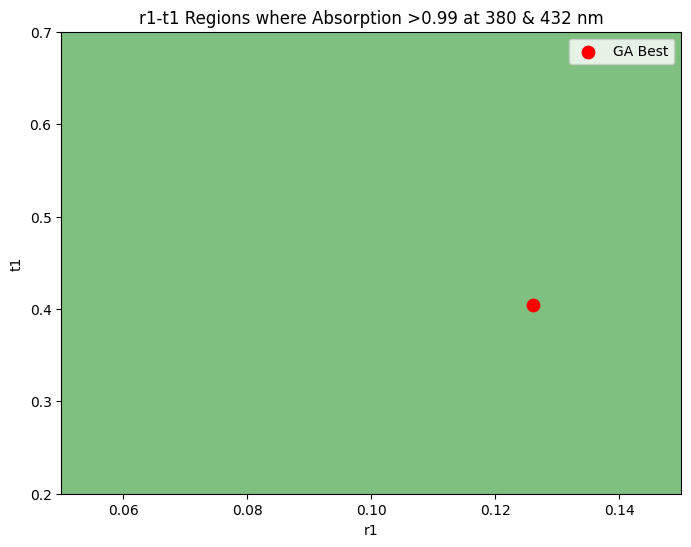

In [6]:
# ======================================================
# Find r1 and t1 for Absorption >0.99 at 380 & 432 nm
# Full code with GA + visualization
# ======================================================

import random, numpy as np, pandas as pd
import matplotlib.pyplot as plt
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import train_test_split
from deap import base, creator, tools, algorithms
import warnings
warnings.filterwarnings('ignore')

# ---------- CONFIG ----------
DATA_FILE = '/kaggle/input/meraj-2/Book1.xlsx'  # update with your path
SEED = 42
POPULATION_SIZE = 50
NUM_GENERATIONS = 200
GRID_POINTS = 80
ABS_THRESHOLD = 0.99
# ----------------------------

random.seed(SEED)
np.random.seed(SEED)

# --- Load and clean data ---
raw = pd.read_excel(DATA_FILE, header=None)
if str(raw.iloc[0,0]).strip().lower() == 'wavelength':
    raw.columns = raw.iloc[0]
    df = raw[1:].copy()
else:
    df = raw.iloc[:, :4].copy()
    df.columns = ['Wavelength','R1','T1','Absorption']

for c in ['Wavelength','R1','T1','Absorption']:
    df[c] = pd.to_numeric(df[c], errors='coerce')
df = df.dropna(subset=['R1','T1','Absorption']).reset_index(drop=True)
df = df[(df['Wavelength']>200) & (df['Wavelength']<1200)].reset_index(drop=True)
print("✅ Data loaded:", len(df), "rows")

# --- Train Random Forest model ---
X = df[['Wavelength','R1','T1']].values
y = df['Absorption'].values
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=SEED)
model = RandomForestRegressor(n_estimators=200, random_state=SEED, n_jobs=-1)
model.fit(X_train, y_train)

# --- Bounds ---
r1_bounds = (float(np.nanmin(df['R1'])), float(np.nanmax(df['R1'])))
t1_bounds = (float(np.nanmin(df['T1'])), float(np.nanmax(df['T1'])))

# ======================================================
# 1️⃣ Brute-force grid search for all points >0.99
# ======================================================
r1_vals = np.linspace(r1_bounds[0], r1_bounds[1], GRID_POINTS)
t1_vals = np.linspace(t1_bounds[0], t1_bounds[1], GRID_POINTS)
R1, T1 = np.meshgrid(r1_vals, t1_vals)

pred_380 = model.predict(np.column_stack([np.full(R1.size, 380), R1.ravel(), T1.ravel()])).reshape(R1.shape)
pred_432 = model.predict(np.column_stack([np.full(R1.size, 432), R1.ravel(), T1.ravel()])).reshape(R1.shape)

# --- Mask points >0.99 for both wavelengths ---
mask_both = (pred_380 >= ABS_THRESHOLD) & (pred_432 >= ABS_THRESHOLD)
r1_good = R1[mask_both]
t1_good = T1[mask_both]

print("\n📌 Grid Search Results:")
if len(r1_good) > 0:
    print(f"Number of points with Absorption >0.99 at both wavelengths: {len(r1_good)}")
    print("Example points:")
    for i in range(min(5, len(r1_good))):
        print(f"r1 = {r1_good[i]:.6f}, t1 = {t1_good[i]:.6f}")
else:
    print("No point found with Absorption >0.99 at both wavelengths.")

# Optional: save all feasible points
pd.DataFrame({'r1': r1_good, 't1': t1_good}).to_csv('r1_t1_abs_gt_0_99.csv', index=False)

# ======================================================
# 2️⃣ GA optimization for best compromise
# ======================================================

# Safe DEAP creator setup
if not hasattr(creator, "FitnessMax"):
    creator.create("FitnessMax", base.Fitness, weights=(1.0,))
if not hasattr(creator, "Individual"):
    creator.create("Individual", list, fitness=creator.FitnessMax)

class GAOptimizerMulti:
    def __init__(self, model, wavelengths, r1_bounds, t1_bounds, pop_size=50, gens=200):
        self.model = model
        self.wl = wavelengths
        self.r1_bounds = r1_bounds
        self.t1_bounds = t1_bounds
        self.pop_size = pop_size
        self.gens = gens

    def run(self):
        toolbox = base.Toolbox()
        toolbox.register("attr_r1", random.uniform, *self.r1_bounds)
        toolbox.register("attr_t1", random.uniform, *self.t1_bounds)
        toolbox.register("individual", tools.initCycle, creator.Individual,
                         (toolbox.attr_r1, toolbox.attr_t1), n=1)
        toolbox.register("population", tools.initRepeat, list, toolbox.individual)

        # Fitness: maximize minimum absorption
        def evalAbsMulti(individual):
            r1, t1 = individual
            preds = [self.model.predict([[wl, r1, t1]])[0] for wl in self.wl]
            return (min(preds),)

        toolbox.register("evaluate", evalAbsMulti)
        toolbox.register("mate", tools.cxBlend, alpha=0.5)
        toolbox.register("mutate", tools.mutPolynomialBounded,
                         low=[self.r1_bounds[0], self.t1_bounds[0]],
                         up=[self.r1_bounds[1], self.t1_bounds[1]],
                         eta=0.5, indpb=0.2)
        toolbox.register("select", tools.selTournament, tournsize=3)

        pop = toolbox.population(n=self.pop_size)
        algorithms.eaSimple(pop, toolbox, cxpb=0.5, mutpb=0.2, ngen=self.gens, verbose=False)
        best = tools.selBest(pop, k=1)[0]
        best_val = evalAbsMulti(best)[0]
        return best, best_val

# Run GA
opt_multi = GAOptimizerMulti(model, wavelengths=[380,432],
                             r1_bounds=r1_bounds, t1_bounds=t1_bounds,
                             pop_size=POPULATION_SIZE, gens=NUM_GENERATIONS)

best_sol, best_fit = opt_multi.run()
r1_best, t1_best = best_sol

# Predicted absorptions at GA best
abs_380 = model.predict([[380, r1_best, t1_best]])[0]
abs_432 = model.predict([[432, r1_best, t1_best]])[0]
status = "✅" if min(abs_380, abs_432) >= ABS_THRESHOLD else "❌"

print("\n🚀 GA Best Compromise Solution:")
print(f"r1 = {r1_best:.6f}, t1 = {t1_best:.6f}")
print(f"Predicted Absorptions → 380 nm: {abs_380:.6f}, 432 nm: {abs_432:.6f}")
print("Status:", status)

# ======================================================
# 3️⃣ Visualization
# ======================================================
plt.figure(figsize=(8,6))
plt.contourf(R1, T1, mask_both, levels=[0,0.5,1], colors=['green'], alpha=0.5)
plt.scatter(r1_best, t1_best, c='red', s=80, label='GA Best')
plt.xlabel('r1'); plt.ylabel('t1')
plt.title('r1-t1 Regions where Absorption >0.99 at 380 & 432 nm')
plt.legend()
plt.show()


✅ Data loaded: 121120 rows

📌 Grid Search Results:
No point found with Absorption >0.99 at both wavelengths.

🚀 GA Best Compromise Solution:
r1 = 0.128499, t1 = 0.392214
Predicted Absorptions → 380 nm: 0.972584, 432 nm: 0.922082
Status: ❌


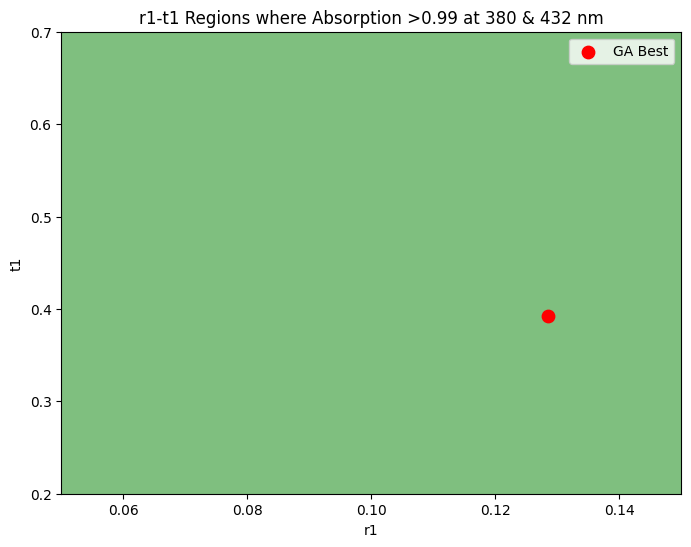


📊 Predicted Absorption for GA best values (r1=0.128499, t1=0.392214):
   Wavelength (nm)  Predicted Absorption
0       360.000000              0.439921
1       363.448276              0.395108
2       366.896552              0.386952
3       370.344828              0.423658
4       373.793103              0.549534
5       377.241379              0.856356
6       380.689655              0.920456
7       384.137931              0.551443
8       387.586207              0.437921
9       391.034483              0.704274


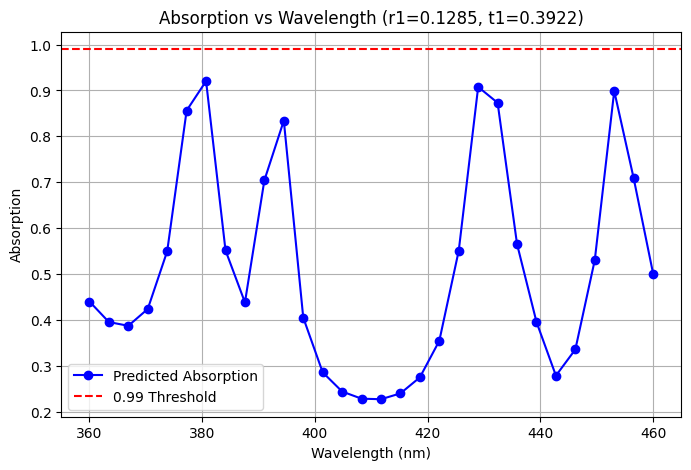

In [1]:
# ======================================================
# Find r1 and t1 for Absorption >0.99 at 380 & 432 nm
# Full code with GA + visualization + 360–460 range
# ======================================================

import random, numpy as np, pandas as pd
import matplotlib.pyplot as plt
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import train_test_split
from deap import base, creator, tools, algorithms
import warnings
warnings.filterwarnings('ignore')

# ---------- CONFIG ----------
DATA_FILE = '/kaggle/input/meraj-2/Book1.xlsx'  # update with your path
SEED = 42
POPULATION_SIZE = 50
NUM_GENERATIONS = 200
GRID_POINTS = 80
ABS_THRESHOLD = 0.99
# ----------------------------

random.seed(SEED)
np.random.seed(SEED)

# --- Load and clean data ---
raw = pd.read_excel(DATA_FILE, header=None)
if str(raw.iloc[0,0]).strip().lower() == 'wavelength':
    raw.columns = raw.iloc[0]
    df = raw[1:].copy()
else:
    df = raw.iloc[:, :4].copy()
    df.columns = ['Wavelength','R1','T1','Absorption']

for c in ['Wavelength','R1','T1','Absorption']:
    df[c] = pd.to_numeric(df[c], errors='coerce')

df = df.dropna(subset=['R1','T1','Absorption']).reset_index(drop=True)
df = df[(df['Wavelength']>200) & (df['Wavelength']<1200)].reset_index(drop=True)
print("✅ Data loaded:", len(df), "rows")

# --- Train Random Forest model ---
X = df[['Wavelength','R1','T1']].values
y = df['Absorption'].values
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=SEED)
model = RandomForestRegressor(n_estimators=200, random_state=SEED, n_jobs=-1)
model.fit(X_train, y_train)

# --- Bounds ---
r1_bounds = (float(np.nanmin(df['R1'])), float(np.nanmax(df['R1'])))
t1_bounds = (float(np.nanmin(df['T1'])), float(np.nanmax(df['T1'])))

# ======================================================
# 1️⃣ Brute-force grid search for all points >0.99
# ======================================================
r1_vals = np.linspace(r1_bounds[0], r1_bounds[1], GRID_POINTS)
t1_vals = np.linspace(t1_bounds[0], t1_bounds[1], GRID_POINTS)
R1, T1 = np.meshgrid(r1_vals, t1_vals)

pred_380 = model.predict(np.column_stack([np.full(R1.size, 380), R1.ravel(), T1.ravel()])).reshape(R1.shape)
pred_432 = model.predict(np.column_stack([np.full(R1.size, 432), R1.ravel(), T1.ravel()])).reshape(R1.shape)

# --- Mask points >0.99 for both wavelengths ---
mask_both = (pred_380 >= ABS_THRESHOLD) & (pred_432 >= ABS_THRESHOLD)
r1_good = R1[mask_both]
t1_good = T1[mask_both]

print("\n📌 Grid Search Results:")
if len(r1_good) > 0:
    print(f"Number of points with Absorption >0.99 at both wavelengths: {len(r1_good)}")
    print("Example points:")
    for i in range(min(5, len(r1_good))):
        print(f"r1 = {r1_good[i]:.6f}, t1 = {t1_good[i]:.6f}")
else:
    print("No point found with Absorption >0.99 at both wavelengths.")

# Optional: save feasible points
pd.DataFrame({'r1': r1_good, 't1': t1_good}).to_csv('r1_t1_abs_gt_0_99.csv', index=False)

# ======================================================
# 2️⃣ GA optimization for best compromise
# ======================================================

# Safe DEAP creator setup
if not hasattr(creator, "FitnessMax"):
    creator.create("FitnessMax", base.Fitness, weights=(1.0,))
if not hasattr(creator, "Individual"):
    creator.create("Individual", list, fitness=creator.FitnessMax)

class GAOptimizerMulti:
    def __init__(self, model, wavelengths, r1_bounds, t1_bounds, pop_size=50, gens=200):
        self.model = model
        self.wl = wavelengths
        self.r1_bounds = r1_bounds
        self.t1_bounds = t1_bounds
        self.pop_size = pop_size
        self.gens = gens

    def run(self):
        toolbox = base.Toolbox()
        toolbox.register("attr_r1", random.uniform, *self.r1_bounds)
        toolbox.register("attr_t1", random.uniform, *self.t1_bounds)
        toolbox.register("individual", tools.initCycle, creator.Individual,
                         (toolbox.attr_r1, toolbox.attr_t1), n=1)
        toolbox.register("population", tools.initRepeat, list, toolbox.individual)

        # Fitness: maximize minimum absorption
        def evalAbsMulti(individual):
            r1, t1 = individual
            preds = [self.model.predict([[wl, r1, t1]])[0] for wl in self.wl]
            return (min(preds),)

        toolbox.register("evaluate", evalAbsMulti)
        toolbox.register("mate", tools.cxBlend, alpha=0.5)
        toolbox.register("mutate", tools.mutPolynomialBounded,
                         low=[self.r1_bounds[0], self.t1_bounds[0]],
                         up=[self.r1_bounds[1], self.t1_bounds[1]],
                         eta=0.5, indpb=0.2)
        toolbox.register("select", tools.selTournament, tournsize=3)

        pop = toolbox.population(n=self.pop_size)
        algorithms.eaSimple(pop, toolbox, cxpb=0.5, mutpb=0.2, ngen=self.gens, verbose=False)
        best = tools.selBest(pop, k=1)[0]
        best_val = evalAbsMulti(best)[0]
        return best, best_val

# Run GA
opt_multi = GAOptimizerMulti(model, wavelengths=[380, 432],
                             r1_bounds=r1_bounds, t1_bounds=t1_bounds,
                             pop_size=POPULATION_SIZE, gens=NUM_GENERATIONS)

best_sol, best_fit = opt_multi.run()
r1_best, t1_best = best_sol

# Predicted absorptions at GA best
abs_380 = model.predict([[380, r1_best, t1_best]])[0]
abs_432 = model.predict([[432, r1_best, t1_best]])[0]
status = "✅" if min(abs_380, abs_432) >= ABS_THRESHOLD else "❌"

print("\n🚀 GA Best Compromise Solution:")
print(f"r1 = {r1_best:.6f}, t1 = {t1_best:.6f}")
print(f"Predicted Absorptions → 380 nm: {abs_380:.6f}, 432 nm: {abs_432:.6f}")
print("Status:", status)

# ======================================================
# 3️⃣ Visualization of feasible region
# ======================================================
plt.figure(figsize=(8,6))
plt.contourf(R1, T1, mask_both, levels=[0,0.5,1], colors=['green'], alpha=0.5)
plt.scatter(r1_best, t1_best, c='red', s=80, label='GA Best')
plt.xlabel('r1')
plt.ylabel('t1')
plt.title('r1-t1 Regions where Absorption >0.99 at 380 & 432 nm')
plt.legend()
plt.show()

# ======================================================
# 4️⃣ Absorption vs Wavelength (360–460 nm)
# ======================================================

# Define wavelength range (30 points between 360–460 nm)
wavelengths = np.linspace(360, 460, 30)

# Predict absorption for each wavelength using GA best r1, t1
abs_values = [model.predict([[wl, r1_best, t1_best]])[0] for wl in wavelengths]

# Combine into a DataFrame
abs_df = pd.DataFrame({
    'Wavelength (nm)': wavelengths,
    'Predicted Absorption': abs_values
})

# Show first few results
print("\n📊 Predicted Absorption for GA best values (r1=%.6f, t1=%.6f):" % (r1_best, t1_best))
print(abs_df.head(10))

# Save to CSV
abs_df.to_csv('absorption_360_460_ga_best.csv', index=False)

# ======================================================
# 5️⃣ Visualization of Absorption Curve
# ======================================================
plt.figure(figsize=(8,5))
plt.plot(wavelengths, abs_values, 'o-', color='blue', label='Predicted Absorption')
plt.axhline(0.99, color='red', linestyle='--', label='0.99 Threshold')
plt.title(f'Absorption vs Wavelength (r1={r1_best:.4f}, t1={t1_best:.4f})')
plt.xlabel('Wavelength (nm)')
plt.ylabel('Absorption')
plt.legend()
plt.grid(True)
plt.show()


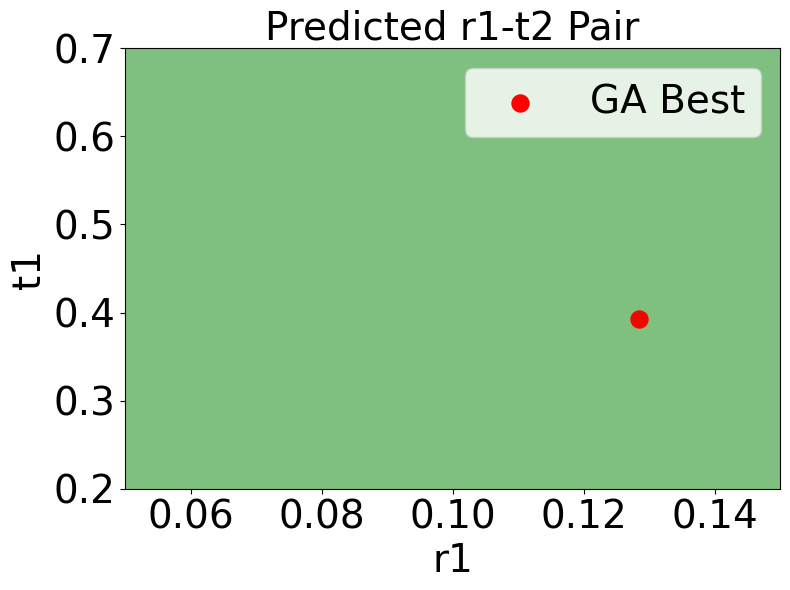

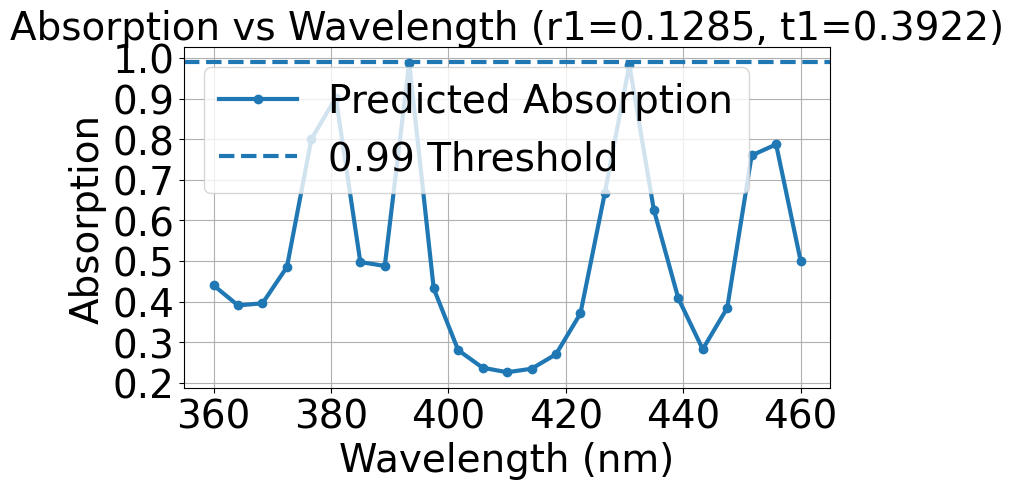

In [5]:
# ======================================================
# 3️⃣ Visualization of feasible region (font size 28)
# ======================================================
plt.figure(figsize=(8,6))
plt.contourf(R1, T1, mask_both, levels=[0,0.5,1], colors=['green'], alpha=0.5)
plt.scatter(r1_best, t1_best, c='red', s=150, label='GA Best')
plt.xlabel('r1', fontsize=28)
plt.ylabel('t1', fontsize=28)
plt.title('Predicted r1-t2 Pair', fontsize=28)
plt.xticks(fontsize=28)
plt.yticks(fontsize=28)
plt.legend(fontsize=28)
plt.tight_layout()
plt.show()

# ======================================================
# 5️⃣ Absorption Curve Visualization (font size 28)
# ======================================================
plt.figure(figsize=(8,5))
plt.plot(wavelengths, abs_values, 'o-', linewidth=3, label='Predicted Absorption')
plt.axhline(0.99, linestyle='--', linewidth=3, label='0.99 Threshold')
plt.title(f'Absorption vs Wavelength (r1={r1_best:.4f}, t1={t1_best:.4f})', fontsize=28)
plt.xlabel('Wavelength (nm)', fontsize=28)
plt.ylabel('Absorption', fontsize=28)
plt.xticks(fontsize=28)
plt.yticks(fontsize=28)
plt.legend(fontsize=28)
plt.grid(True)
plt.tight_layout()
plt.show()


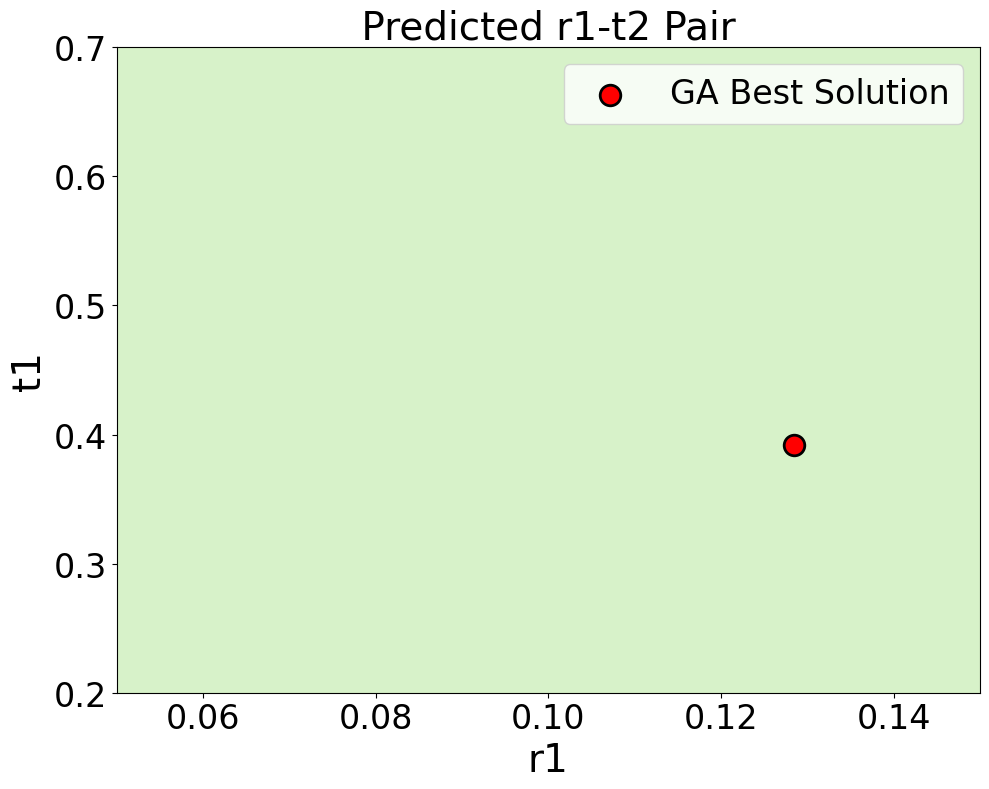

In [12]:
# ================================
# Beautiful Journal-Style Figure
# Feasible Region (Abs > 0.99)
# ================================
plt.figure(figsize=(10,8))

# Smooth contour shading
plt.contourf(
    R1, T1, mask_both,
    levels=[0, 0.5, 1],
    colors=["#d0f0c0"],   # soft green
    alpha=0.85
)

# Black contour boundary
plt.contour(
    R1, T1, mask_both,
    levels=[0.5],
    colors="black",
    linewidths=2.5
)

# GA best point
plt.scatter(
    r1_best, t1_best,
    c="red",
    s=220,
    edgecolors="black",
    linewidth=2,
    label="GA Best Solution"
)

plt.xlabel("r1", fontsize=28)
plt.ylabel("t1", fontsize=28)
plt.title(" Predicted r1-t2 Pair ", fontsize=28)

plt.xticks(fontsize=24)
plt.yticks(fontsize=24)
plt.legend(fontsize=24, loc="best", frameon=True)

plt.grid(False)
plt.tight_layout()
plt.show()



🌟 Best Predicted Absorption:
Wavelength = 380.690 nm
Absorption = 0.920456


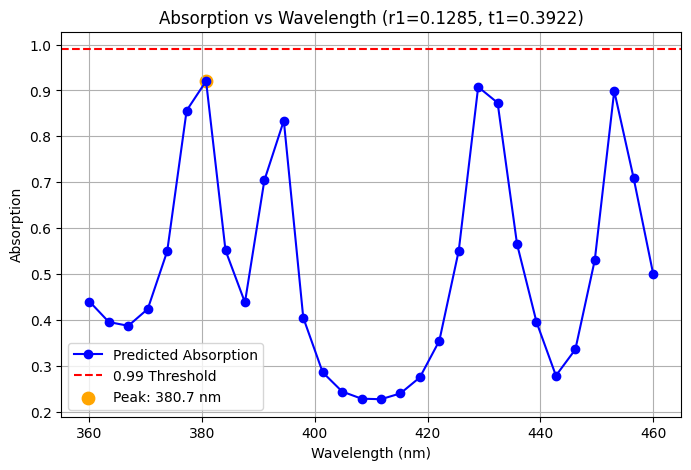

In [2]:
# ======================================================
# 6️⃣ Find wavelength with maximum predicted absorption
# ======================================================
max_idx = abs_df['Predicted Absorption'].idxmax()
best_wavelength = abs_df.loc[max_idx, 'Wavelength (nm)']
best_absorption = abs_df.loc[max_idx, 'Predicted Absorption']

print("\n🌟 Best Predicted Absorption:")
print(f"Wavelength = {best_wavelength:.3f} nm")
print(f"Absorption = {best_absorption:.6f}")

# Mark it on the plot
plt.figure(figsize=(8,5))
plt.plot(abs_df['Wavelength (nm)'], abs_df['Predicted Absorption'], 'o-', color='blue', label='Predicted Absorption')
plt.axhline(0.99, color='red', linestyle='--', label='0.99 Threshold')
plt.scatter(best_wavelength, best_absorption, color='orange', s=80, label=f'Peak: {best_wavelength:.1f} nm')
plt.title(f'Absorption vs Wavelength (r1={r1_best:.4f}, t1={t1_best:.4f})')
plt.xlabel('Wavelength (nm)')
plt.ylabel('Absorption')
plt.legend()
plt.grid(True)
plt.show()


✅ Saved predicted absorption data to 'absorption_360_460_fixed_r1_t1.csv'
   Wavelength (nm)  Predicted Absorption
0       360.000000              0.439921
1       364.166667              0.390560
2       368.333333              0.395644
3       372.500000              0.484927
4       376.666667              0.800090
5       380.833333              0.902147
6       385.000000              0.497260
7       389.166667              0.487675
8       393.333333              0.988003
9       397.500000              0.432429


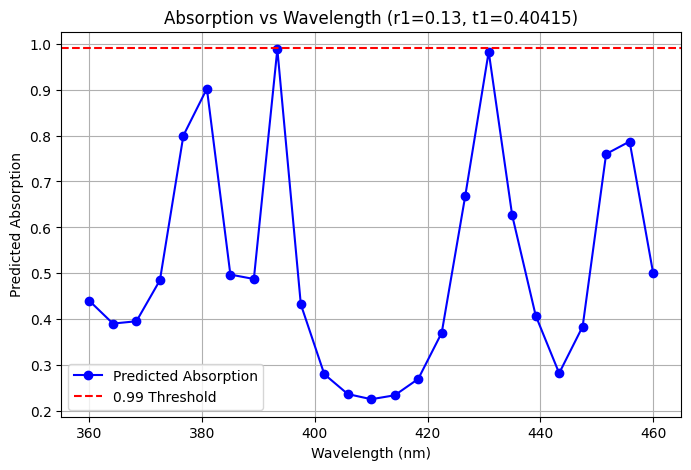

In [3]:
# ======================================================
# Predict Absorption for given r1=0.13, t1=0.40415
# Across 20–30 wavelengths (360–460 nm)
# ======================================================

import numpy as np, pandas as pd, matplotlib.pyplot as plt

# --- your trained RandomForest model must already exist ---
# (make sure you already ran the model training part above)

# Fixed r1, t1
r1_fixed = 0.13
t1_fixed = 0.40415

# Generate 25 wavelengths between 360 and 460 nm
wavelengths = np.linspace(360, 460, 25)

# Predict absorption for each wavelength
abs_values = [model.predict([[wl, r1_fixed, t1_fixed]])[0] for wl in wavelengths]

# Create DataFrame
abs_df = pd.DataFrame({
    'Wavelength (nm)': wavelengths,
    'Predicted Absorption': abs_values
})

# Save to CSV
output_file = 'absorption_360_460_fixed_r1_t1.csv'
abs_df.to_csv(output_file, index=False)
print(f"✅ Saved predicted absorption data to '{output_file}'")

# Show first few rows
print(abs_df.head(10))

# Plot absorption vs wavelength
plt.figure(figsize=(8,5))
plt.plot(wavelengths, abs_values, 'o-', color='blue', label='Predicted Absorption')
plt.axhline(0.99, color='red', linestyle='--', label='0.99 Threshold')
plt.title(f'Absorption vs Wavelength (r1={r1_fixed}, t1={t1_fixed})')
plt.xlabel('Wavelength (nm)')
plt.ylabel('Predicted Absorption')
plt.legend()
plt.grid(True)
plt.show()
